# Dépendance

## Import

### Lasp

In [1]:
import lasp.io
import lasp.filters.linear
import lasp.utils
import lasp.noise
import lasp.convert
from lasp.geometry import *

### Torch

In [2]:
import torch
import ignite.metrics

### Others

In [1]:
import pathlib
import shutil
import numpy
import pandas
import scipy.signal
import matplotlib.pyplot
from datasets import load_dataset
from PIL import Image

# Make dataset

In [4]:
# Value for background image
BACKGROUNG = 1.0
# Value for geometry form
GEOMETRY = 0.5

CMAP = 'gray'

In [5]:
def piece_wise_1():

    img = numpy.full(shape=(512, 512), fill_value=BACKGROUNG, dtype=numpy.float_)

    img = make_square(
        img = img,
        p1 = numpy.array([100, 100]),
        p2 = numpy.array([200, 200]),
        value=GEOMETRY
    )
    img = make_circle(img, numpy.array([100, 300]), 40, value=GEOMETRY)
    img = make_star(img, numpy.array([300, 300]), numpy.array([300, 300]) + 200, value=GEOMETRY)

    return img

In [6]:
def piece_wise_2():

    img = numpy.full(shape=(512, 512), fill_value=BACKGROUNG, dtype=numpy.float_)

    img = make_triangle(
        img,
        p1 = numpy.array([200, 100]),
        p2 = numpy.array([250, 300]),
        p3 = numpy.array([150, 300]),
        value=GEOMETRY
    )
    img = make_circle(img, numpy.array([300, 300]), 40, value=GEOMETRY)
    img = make_star(img, numpy.array([100, 300]), numpy.array([100, 300]) + 200, value=GEOMETRY)

    return img

In [7]:
def piece_wise_3():

    img = numpy.full(shape=(512, 512), fill_value=BACKGROUNG, dtype=numpy.float_)
    xi = numpy.array([100, 100])
    yi = xi + 100

    img = make_triangle(
        img,
        p1 = numpy.array([100, 10]),
        p2 = numpy.array([100, 100]),
        p3 = numpy.array([150, 300]),
        value=1.0
    )

    img = make_partial_circle(img, numpy.array([400, 100]), 40, 50, value=GEOMETRY)
    img = make_star(img, numpy.array([100, 300]), numpy.array([100, 300]) + 100, value=GEOMETRY)

    img = make_star(img, numpy.array([300, 300]), numpy.array([300, 300]) + 100, value=GEOMETRY)

    return img

In [8]:
def piece_wise_4():

    img = numpy.full(shape=(512, 512), fill_value=BACKGROUNG, dtype=numpy.float_)

    img = make_partial_circle(
        img = img,
        center = numpy.array([100, 100]),
        radius_min = 20,
        radius_max = 40,
        value=GEOMETRY
    )

    img = make_circle(
        img = img,
        center = numpy.array([200, 200]),
        radius = 40,
        value=GEOMETRY
    )


    img = make_partial_circle(
        img = img,
        center = numpy.array([100, 300]),
        radius_min = 20,
        radius_max = 40,
        value=GEOMETRY
    )

    img = make_circle(
        img = img,
        center = numpy.array([200, 300]),
        radius = 40,
        value=GEOMETRY
    )

    img = make_square(
        img = img,
        p1 = numpy.array([300, 400]),
        p2 = numpy.array([400, 500]),
        value=GEOMETRY
    )

    img = make_partial_circle(
        img = img,
        center = numpy.array([400, 400]),
        radius_min = 50,
        radius_max = 80,
        value=BACKGROUNG
    )

    return img

In [9]:
dataset_choice = "SegmentationOfTeethPanoramicXRayImages"
if dataset_choice == "normalforme" :
    img1 = piece_wise_1()
    img2 = piece_wise_2()
    img3 = piece_wise_3()
    img4 = piece_wise_4()
elif dataset_choice == "SegmentationOfTeethPanoramicXRayImages" :
    dataset = load_dataset("SerdarHelli/SegmentationOfTeethPanoramicXRayImages")
    train_data = dataset['train']
    target_height = 1144
    target_width = 2800
    img1 = numpy.array(train_data[0]['image'].resize((target_width, target_height), resample=Image.Resampling.LANCZOS))
    img2 = numpy.array(train_data[1]['image'].resize((target_width, target_height), resample=Image.Resampling.LANCZOS))
    img3 = numpy.array(train_data[2]['image'].resize((target_width, target_height), resample=Image.Resampling.LANCZOS))
    img4 = numpy.array(train_data[3]['image'].resize((target_width, target_height), resample=Image.Resampling.LANCZOS))

In [10]:
imgs = [ img1, img2, img3, img4 ]

In [ ]:
for img in imgs:
    

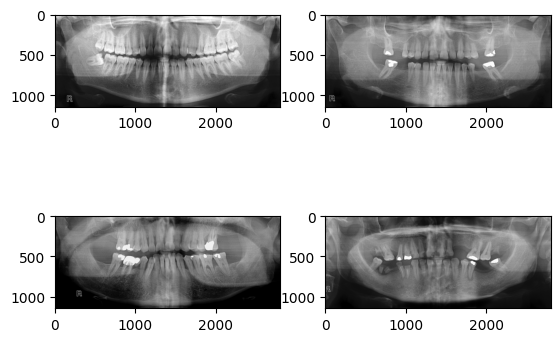

In [11]:
figure = matplotlib.pyplot.figure()

matplotlib.pyplot.subplot(2, 2, 1)
_ = matplotlib.pyplot.imshow(img1, cmap=CMAP)

matplotlib.pyplot.subplot(2, 2, 2)
_ = matplotlib.pyplot.imshow(img2, cmap=CMAP)

matplotlib.pyplot.subplot(2, 2, 3)
_ = matplotlib.pyplot.imshow(img3, cmap=CMAP)

matplotlib.pyplot.subplot(2, 2, 4)
_ = matplotlib.pyplot.imshow(img4, cmap=CMAP)

figure.show()

In [12]:
if dataset_choice == "normalforme" :
    DATASET_PATH = pathlib.Path("./data/dataset1/")
elif dataset_choice == "SegmentationOfTeethPanoramicXRayImages" :
    DATASET_PATH = pathlib.Path("./data/dataset2/")
if DATASET_PATH.exists():
    shutil.rmtree(DATASET_PATH)
    print(f"Dataset réinitialisé : {DATASET_PATH} est de nouveau propre.")
if not(DATASET_PATH.exists()):
    DATASET_PATH.mkdir()
IMAGES_PATH = DATASET_PATH / "Images"
if not(IMAGES_PATH.exists()):
    IMAGES_PATH.mkdir()

Dataset réinitialisé : data/dataset2 est de nouveau propre.


In [13]:
for i in range(0, len(imgs)):
    lasp.io.save(imgs[i], IMAGES_PATH / '{}.npy'.format(i))

# Make Dataframe

In [14]:
def add_image(
    df_imgs: pandas.DataFrame,
    original: pathlib.Path,
    blur: tuple[int, int] = (0, 0),
    decimation: int = 1,
    noise: float = -1,
    noise_db: float = -1
) -> pandas.DataFrame :
    to_add = pandas.DataFrame(
        {
            'original': [original],
            'blur' : [blur],
            'decimation': [decimation],
            'noise (not dB)': [noise],
            'noise (dB)': [noise_db]
        }
    )
    return pandas.concat([df_imgs,  to_add], ignore_index=True)

In [15]:
df_imgs = pandas.DataFrame(columns=[ 'original', 'blur', 'decimation', 'noise (not dB)', 'noise (dB)' ])
noise = lasp.convert.snrdb_to_snr(60)

for i in range(1, 3):

    decimation = 2**i

    for img in IMAGES_PATH.glob('*'):

            # for snr_db in [ 10, 20, 30, 40, 50, 60 ]:
            for snr_db in range(10, 30, 5):

                noise = lasp.convert.snrdb_to_snr(snr_db)
                #
                #for blur in [ (7, 3), (9, 3), (15, 3), (21, 3), (45, 3) ]:

                    #df_imgs = add_image(df_imgs, img, blur, decimation, noise, snr_db)
                for size_sigma in range(5, 20, 5):

                    df_imgs = add_image(df_imgs, img, (size_sigma, size_sigma), decimation, noise, snr_db)
df_imgs

,original,blur,decimation,noise (not dB),noise (dB)
0,data/dataset2/Images/0.npy,"(5, 5)",2,10.000000,10
1,data/dataset2/Images/0.npy,"(10, 10)",2,10.000000,10
2,data/dataset2/Images/0.npy,"(15, 15)",2,10.000000,10
3,data/dataset2/Images/0.npy,"(5, 5)",2,31.622777,15
4,data/dataset2/Images/0.npy,"(10, 10)",2,31.622777,15
...,...,...,...,...,...
91,data/dataset2/Images/3.npy,"(10, 10)",4,100.000000,20
92,data/dataset2/Images/3.npy,"(15, 15)",4,100.000000,20
93,data/dataset2/Images/3.npy,"(5, 5)",4,316.227766,25
94,data/dataset2/Images/3.npy,"(10, 10)",4,316.227766,25


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from pathlib import Path
from sklearn.model_selection import train_test_split
import lasp  # ton module existant
import os


def make_dataset_images(df_imgs: pd.DataFrame, output_dir: Path, split_ratio=(0.7, 0.15, 0.15)) -> None:
    # --- 1. Crée les splits ---
    train_df, temp_df = train_test_split(df_imgs, test_size=(1 - split_ratio[0]), random_state=42)
    val_size = split_ratio[1] / (split_ratio[1] + split_ratio[2])
    val_df, test_df = train_test_split(temp_df, test_size=(1 - val_size), random_state=42)

    splits = {
        "train": train_df,
        "val": val_df,
        "test": test_df
    }

    # --- 2. Boucle sur chaque split ---
    # Fichier unique des paramètres pour chaque split
    # Format CSV pour relecture facile en DataFrame
    for split_name, split_df in splits.items():
        print(f"🔹 Génération du split {split_name} ({len(split_df)} images)")

        split_dir = Path(output_dir) / split_name
        input_dir = split_dir / "input"
        gt_dir = split_dir / "ground_truth"
        plot_dir = split_dir / "plots"
        params_file = split_dir / "params.csv"  # dossier supplémentaire pour stocker les paramètres

        input_dir.mkdir(parents=True, exist_ok=True)
        gt_dir.mkdir(parents=True, exist_ok=True)
        plot_dir.mkdir(parents=True, exist_ok=True)
        

        # Prépare le fichier CSV
        with open(params_file, "w") as f_params:
            f_params.write("id,blur_size,blur_sigma,decimation,noise_value,noise_db,original_file")

        for i, index in enumerate(split_df.index):
            img_datas = split_df.loc[index]

            img_path = img_datas['original']
            blur = img_datas['blur']
            decim = img_datas['decimation']
            noise = img_datas['noise (not dB)']
            noise_db = img_datas['noise (dB)']

            # --- Lecture et normalisation ---
            out = lasp.io.read(img_path)
            ground_truth_normalized = lasp.utils.normalize(out)
            lasp.io.save(ground_truth_normalized, gt_dir / f"{i}.npy")

            title = ''
            params = {}  # dictionnaire des paramètres pour cette image

            # --- Blur ---
            if (blur[0] > 0) and (blur[1] > 0):
                kernel = lasp.filters.linear.gaussian_filter(size=blur[0], sigma=blur[1])
                out = scipy.signal.convolve2d(out, kernel, mode='same')
                title += f"Blur filter: {blur[0]}x{blur[0]}, σ={blur[1]}\n"
                params['blur'] = {"size": blur[0], "sigma": blur[1]}
            else:
                params['blur'] = None

            # --- Décimation ---
            if decim > 0:
                out = lasp.utils.decimation(out, decim)
                title += f"Decimation: {decim}x{decim}\n"
                params['decimation'] = decim
            else:
                params['decimation'] = None

            # --- Bruit ---
            if noise >= 0:
                out = lasp.noise.awgn(out, noise)
                title += f"Noise: {noise} (not dB)\nNoise: {noise_db} (dB)\n"
                params['noise'] = {"value": noise, "db": noise_db}
            else:
                params['noise'] = None

            # --- Normalisation finale ---
            normalized = lasp.utils.normalize(out)
            lasp.io.save(normalized, input_dir / f"{i}.npy")

                        # --- Ajout des paramètres au fichier CSV ---
            with open(params_file, "a") as f_params:
                blur_size = params['blur']["size"] if params['blur'] else ""
                blur_sigma = params['blur']["sigma"] if params['blur'] else ""
                deci = params['decimation'] if params['decimation'] else ""
                noise_val = params['noise']["value"] if params['noise'] else ""
                noise_dB = params['noise']["db"] if params['noise'] else ""

                f_params.write(f"\n{i},{blur_size},{blur_sigma},{deci},{noise_val},{noise_dB},{img_path}")

            # --- Sauvegarde de l’aperçu ---
            with plt.ioff():
                fig, ax = plt.subplots(1, 2, figsize=(8, 4))
                fig.suptitle(title, fontsize=10)

                ax[0].set_title("Normalized Input")
                ax[0].imshow(normalized, cmap="gray")

                ax[1].set_title("Normalized Ground Truth")
                ax[1].imshow(ground_truth_normalized, cmap="gray")

                fig.tight_layout()
                fig.subplots_adjust(top=0.85)

                fig.savefig(plot_dir / f"{i}.png")
                plt.close(fig)

    print("✅ Dataset complet généré avec succès !")


In [17]:
make_dataset_images(df_imgs, DATASET_PATH)

🔹 Génération du split train (67 images)
🔹 Génération du split val (14 images)
🔹 Génération du split test (15 images)
✅ Dataset complet généré avec succès !
